# Hyperparameters and lags search: backtesting vs one-step-ahead

Hyperparameter and lag tuning involves systematically testing different values or combinations of hyperparameters (and/or lags) to find the optimal configuration that gives the best performance. The **skforecast** library provides two different methods to evaluate each candidate configuration:

+ **Backtesting**: In this method, the model predicts several steps ahead in each iteration, using the same forecast horizon and retraining frequency strategy that would be used if the model were deployed. This simulates a real forecasting scenario where the model is retrained and updated over time. More information [here](../user_guides/backtesting.html).

+ **One-Step Ahead**: Evaluates the model using only one-step-ahead predictions. This method is faster because it requires fewer iterations, but it only tests the model's performance in the immediate next time step ($t+1$).

Each method uses a different evaluation strategy, so they may produce different results. However, in the long run, both methods are expected to converge to similar selections of optimal hyperparameters. The one-step-ahead method is much faster than backtesting because it requires fewer iterations, but it only tests the model's performance in the immediate next time step. It is recommended to backtest the final model for a more accurate multi-step performance estimate.

The document compares the performance of these two methods when applied to various datasets and forecaster types. The process is outlined as follows:

+ Optimal hyperparameters and lags are identified through a search using both backtesting and one-step-ahead evaluation methods. This search is performed on the validation partition, and the best configuration is stored along with the time taken to complete the search.

+ Finally, the selected best configuration is evaluated on the test partition using a backtesting procedure.

It is important to note that the final evaluation is consistently performed using backtesting to simulate a real-world multi-step forecasting scenario.

## Results

The results show a significant reduction in the time required to find the optimal configuration using the one-step-ahead method (top panel). However, the performance of the selected configuration on the test partition is similar for both methods (lower panel), with no clear winner. These results are consistent for both grid search and Bayesian search approaches.

<div style="text-align: center;">
    <img src="../img/grid_search_benchmark.png" alt="Grid Search Results" width="700"/>
</div>

<div style="text-align: center;">
    <img src="../img/bayesian_search_benchmark.png" alt="Grid Search Results" width="700"/>
</div>

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

The purpose of this analysis is to compare the time and forecasting performance of the two available evaluation methods, not to compare different forecasters.

</div>

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import platform
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from copy import copy
import sklearn
import skforecast
import lightgbm
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, OneStepAheadFold
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import bayesian_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.direct import ForecasterDirectMultiVariate
from skforecast.model_selection import backtesting_forecaster_multiseries
from skforecast.model_selection import grid_search_forecaster_multiseries
from skforecast.model_selection import bayesian_search_forecaster_multiseries
from skforecast.preprocessing import reshape_series_long_to_dict
from skforecast.preprocessing import reshape_exog_long_to_dict

# Warnings
# ==============================================================================
import warnings
from skforecast.exceptions import IgnoredArgumentWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [2]:
# Versions
# ==============================================================================
print(f"Python version      : {platform.python_version()}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"skforecast version  : {skforecast.__version__}")
print(f"lightgbm version    : {lightgbm.__version__}")
print(f"pandas version      : {pd.__version__}")
print(f"numpy version       : {np.__version__}")
print("")

# System information
# ==============================================================================
print(f"Machine type: {platform.machine()}")
print(f"Processor type: {platform.processor()}")
print(f"Platform type: {platform.platform()}")
print(f"Operating system: {platform.system()}")
print(f"Operating system release: {platform.release()}")
print(f"Operating system version: {platform.version()}")
print(f"Number of physical cores: {psutil.cpu_count(logical=False)}")
print(f"Number of logical cores: {psutil.cpu_count(logical=True)}")

Python version      : 3.13.13
scikit-learn version: 1.9.0
skforecast version  : 0.23.0
lightgbm version    : 4.6.0
pandas version      : 2.3.3
numpy version       : 2.4.6

Machine type: x86_64
Processor type: 
Platform type: Linux-7.0.0-1006-aws-x86_64-with-glibc2.43
Operating system: Linux
Operating system release: 7.0.0-1006-aws
Operating system version: #6-Ubuntu SMP PREEMPT Tue May 26 12:04:34 UTC 2026
Number of physical cores: 8
Number of logical cores: 16


In [3]:
# Import data
# ==============================================================================
data_bike = fetch_dataset('bike_sharing_extended_features', verbose=False)

data_sales = fetch_dataset(name="items_sales", verbose=False)
data_sales = data_sales * 100
data_sales['day_of_week'] = data_sales.index.dayofweek

data_website = fetch_dataset(name="website_visits", raw=True, verbose=False)
data_website['date'] = pd.to_datetime(data_website['date'], format='%d/%m/%y')
data_website = data_website.set_index('date')
data_website = data_website.asfreq('1D')
data_website = data_website.sort_index()
data_website['month'] = data_website.index.month
data_website['month_day'] = data_website.index.day
data_website['week_day'] = data_website.index.day_of_week
data_website = pd.get_dummies(data_website, columns=['month', 'week_day', 'month_day'], dtype='int64')

data_electricity = fetch_dataset(name='vic_electricity', raw=False, verbose=False)
data_electricity = data_electricity.drop(columns="Date")
data_electricity = (
    data_electricity
    .resample(rule="h", closed="left", label="right")
    .agg({
        "Demand": "mean",
        "Temperature": "mean",
        "Holiday": "mean",
    })
)
data_electricity = data_electricity.loc['2012-01-01 00:00:00': '2013-12-30 23:00:00'].copy()

series_dict = pd.read_csv(
    'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/demo_multi_series.csv'
)
exog_dict = pd.read_csv(
    'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/demo_multi_series_exog.csv'
)
series_dict['timestamp'] = pd.to_datetime(series_dict['timestamp'])
exog_dict['timestamp'] = pd.to_datetime(exog_dict['timestamp'])

series_dict = reshape_series_long_to_dict(
    data      = series_dict,
    series_id = 'series_id',
    index     = 'timestamp',
    values    = 'value',
    freq      = 'D'
)
exog_dict = reshape_exog_long_to_dict(
    data      = exog_dict,
    series_id = 'series_id',
    index     = 'timestamp',
    freq      = 'D'
)

## Benchmark

In [4]:
# Functions to compare results using backtesting and one step ahead
# ==============================================================================
def run_benchmark(
    data,
    forecaster_to_benchmark,
    search_method = None,
    lags_grid = None,
    param_grid = None,
    search_space = None,
    end_train = None,
    end_validation = None,
    target = None,
    exog_features = None,
    steps = None,
    metric = None
):
    """
    Compare results of grid search and bayesian search using backtesting and one-step-ahead.
    """
    
    # backtesting
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_train]),
            steps              = steps,
            refit              = False,
         )
    if search_method == 'grid_search':
        results_1 = grid_search_forecaster(
                        forecaster    = forecaster,
                        y             = data.loc[:end_validation, target],
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        n_jobs        = 'auto',
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_1, _ = bayesian_search_forecaster(
                           forecaster    = forecaster,
                           y             = data.loc[:end_validation, target],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           cv            = cv,
                           search_space  = search_space,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           n_jobs        = 'auto',
                           verbose       = False,
                           show_progress = False
                       )

    end = time()
    time_1 = end - start
    best_params = results_1.loc[0, 'params']
    best_lags = results_1.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_1, _ = backtesting_forecaster(
                      forecaster    = forecaster,
                      y             = data.loc[:, target],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    # One step ahead
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = OneStepAheadFold(initial_train_size = len(data.loc[:end_train]))
    if search_method == 'grid_search':
        results_2 = grid_search_forecaster(
                        forecaster    = forecaster,
                        y             = data.loc[:end_validation, target],
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_2, _ = bayesian_search_forecaster(
                           forecaster    = forecaster,
                           y             = data.loc[:end_validation, target],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           cv            = cv,
                           search_space  = search_space,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           verbose       = False,
                           show_progress = False
                       )

    end = time()
    time_2 = end - start
    best_params = results_2.loc[0, 'params']
    best_lags = results_2.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_2, _ = backtesting_forecaster(
                      forecaster    = forecaster,
                      y             = data.loc[:, target],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    print("-----------------")
    print("Benchmark results")
    print("-----------------")
    print('Execution time backtesting   :', time_1)
    print('Execution time one step ahead:', time_2)
    print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
    print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
    print("")
    print("Method: backtesting")
    print(f"    lags   : {results_1.loc[0, 'lags']}")
    print(f"    params : {results_1.loc[0, 'params']}")
    print(f"    {metric}: {metric_1.loc[0, metric]}")
    print("")
    print("Method: one step ahead")
    print(f"    lags   : {results_2.loc[0, 'lags']}")
    print(f"    params : {results_2.loc[0, 'params']}")
    print(f"    {metric}: {metric_2.loc[0, metric]}")
    
    return time_1, time_2, metric_1.loc[0, metric], metric_2.loc[0, metric]


# Functions to compare results using backtesting and one step ahead
# ==============================================================================
def run_benchmark_multiseries(
    data = None,
    forecaster_to_benchmark = None,
    search_method = None,
    lags_grid = None,
    param_grid = None,
    search_space = None,
    end_train = None,
    end_validation = None,
    levels = None,
    exog_features = None,
    steps = None,
    metric = None
):
    """
    Compare results of grid search using backtesting and one-step-ahead.
    """
    
    # Backtesting
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = TimeSeriesFold(
                initial_train_size = len(data.loc[:end_train]),
                steps              = steps,
                refit              = False,
             )
    if search_method == 'grid_search':
        results_1 = grid_search_forecaster_multiseries(
                        forecaster    = forecaster,
                        series        = data.loc[:end_validation, levels],
                        levels        = levels,
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        n_jobs        = 'auto',
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_1, _ = bayesian_search_forecaster_multiseries(
                           forecaster    = forecaster,
                           series        = data.loc[:end_validation, levels],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           levels        = levels,
                           search_space  = search_space,
                           cv            = cv,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           n_jobs        = 'auto',
                           verbose       = False,
                           show_progress = False
                       )
    end = time()
    time_1 = end - start
    best_params = results_1.loc[0, 'params']
    best_lags = results_1.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_1, _ = backtesting_forecaster_multiseries(
                      forecaster    = forecaster,
                      series        = data.loc[:, levels],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      levels        = levels,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    # One step ahead
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = OneStepAheadFold(initial_train_size = len(data.loc[:end_train]))
    if search_method == 'grid_search':
        results_2 = grid_search_forecaster_multiseries(
                        forecaster    = forecaster,
                        series        = data.loc[:end_validation, levels],
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        levels        = levels,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_2, _ = bayesian_search_forecaster_multiseries(
                           forecaster    = forecaster,
                           series        = data.loc[:end_validation, levels],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           cv            = cv,
                           levels        = levels,
                           search_space  = search_space,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           verbose       = False,
                           show_progress = False
                       )

    end = time()
    time_2 = end - start
    best_params = results_2.loc[0, 'params']
    best_lags = results_2.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_2, _ = backtesting_forecaster_multiseries(
                      forecaster    = forecaster,
                      series        = data.loc[:, levels],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      levels        = levels,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    print("Benchmark results")
    print("-----------------")
    print('Execution time backtesting   :', time_1)
    print('Execution time one step ahead:', time_2)
    print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
    print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
    print("")
    print("Method: backtesting")
    print(f"    lags   : {results_1.loc[0, 'lags']}")
    print(f"    params : {results_1.loc[0, 'params']}")
    print(f"    {metric_1.loc[0, metric]}")
    print("")
    print("Method: one step ahead")
    print(f"    lags   : {results_2.loc[0, 'lags']}")
    print(f"    params : {results_2.loc[0, 'params']}")
    print(f"    {metric_2.loc[0, metric]}")
    
    return time_1, time_2, metric_1.loc[0, metric], metric_2.loc[0, metric]


def summarize_results(results, metric, title, plot=True, save_plot=None, fig_size=(8, 4)):
    """
    Summarize results of benchmark.
    """

    results = pd.DataFrame(
        results,
        columns=[
            "dataset",
            "forecaster",
            "time_search_backtesting",
            "time_search_one_step",
            "metric_backtesting",
            "metric_one_step",
        ]
    )
    results['ratio_speed'] = (
        results['time_search_backtesting'] / results['time_search_one_step']
    ).round(2)
    results['ratio_metric'] = (
        results['metric_backtesting'] / results['metric_one_step']
    ).round(2)
    results["dataset_forecaster"] = (
        results["dataset"]
        + " \n "
        + results["forecaster"].str.replace("Forecaster", "")
    )
    display(results)

    if plot:
        set_dark_theme()
        fig, axs = plt.subplots(2, 1, figsize=fig_size, sharex=True)
        results.plot.bar(
            x='dataset_forecaster',
            y=['time_search_backtesting', 'time_search_one_step'],
            ax=axs[0],
        )
        axs[0].set_ylabel('time (s)')
        axs[0].legend(["backtesting", "one-step-ahead"])
        results.plot.bar(
            x='dataset_forecaster',
            y=['metric_backtesting', 'metric_one_step'],
            ax=axs[1],
            legend=False
        )
        axs[1].set_ylabel(f'{metric}')
        axs[1].set_xlabel('')
        plt.xticks(rotation=90)
        plt.suptitle(title)
        plt.tight_layout()

        if save_plot:
            plt.savefig(save_plot, dpi=300, bbox_inches='tight')

### Grid search

In [5]:
# Results
# ==============================================================================
results_grid_search = []
metric = 'mean_absolute_error'

In [6]:
# Dataset bike_sharing_extended_features - ForecasterRecursive
# ==============================================================================
end_train = '2012-03-31 23:59:00'
end_validation = '2012-08-31 23:59:00'
exog_features = [
    'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'week_day_sin',
    'week_day_cos', 'hour_day_sin', 'hour_day_cos', 'sunrise_hour_sin', 'sunrise_hour_cos',
    'sunset_hour_sin', 'sunset_hour_cos', 'holiday_previous_day', 'holiday_next_day',
    'temp_roll_mean_1_day', 'temp_roll_mean_7_day', 'temp_roll_max_1_day',
    'temp_roll_min_1_day', 'temp_roll_max_7_day', 'temp_roll_min_7_day',
    'temp', 'holiday'
]

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )
lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_grid_search.append([
    'bike',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 22.334797859191895
Execution time one step ahead: 5.892937421798706
Same lags   : False
Same params : True

Method: backtesting
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
    mean_absolute_error: 58.276762590192014

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
    mean_absolute_error: 64.04254202108999


In [7]:
# Dataset bike_sharing_extended_features - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 steps         = 24,
                 lags          = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'bike',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 37.69299340248108
Execution time one step ahead: 1.0716171264648438
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': np.float64(112.88378916846884)}
    mean_absolute_error: 79.14111581771617

Method: one step ahead
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'alpha': np.float64(12.742749857031322)}
    mean_absolute_error: 111.95615163625293


In [8]:
# Dataset website_visits - ForecasterRecursive
# ==============================================================================
end_train = '2021-03-30 23:59:00'
end_validation = '2021-06-30 23:59:00'
exog_features = [col for col in data_website.columns if col.startswith(('month_', 'week_day_', 'month_day_'))]

forecaster = ForecasterRecursive(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10
             )

lags_grid = [7, 14, 21, [7, 14, 21]]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 7,
    metric                  = metric
)
results_grid_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 2.7270495891571045
Execution time one step ahead: 0.24204373359680176
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(6.158482110660261)}
    mean_absolute_error: 162.11396980738596

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(2.976351441631316)}
    mean_absolute_error: 162.35163466017008


In [9]:
# Dataset website_visits - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator = Ridge(random_state=123),
                 steps     = 24,
                 lags      = 10
             )

lags_grid = [7, 14, 21, [7, 14, 21]]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 4.444652795791626
Execution time one step ahead: 0.421097993850708
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(6.158482110660261)}
    mean_absolute_error: 277.83625131751756

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(1.438449888287663)}
    mean_absolute_error: 236.2856021897274


In [10]:
# Dataset vic_electricity - ForecasterRecursive
# ==============================================================================
end_train = '2013-06-30 23:59:00'
end_validation = '2013-11-30 23:59:00'
exog_features = ['Temperature', 'Holiday']

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 19.504291534423828
Execution time one step ahead: 5.045478820800781
Same lags   : False
Same params : True

Method: backtesting
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
    mean_absolute_error: 194.83553235066182

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
    mean_absolute_error: 188.8782299908785


In [11]:
# Dataset vic_electricity - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 steps         = 24,
                 lags          = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 32.797258138656616
Execution time one step ahead: 0.8935267925262451
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': np.float64(6.158482110660261)}
    mean_absolute_error: 304.22332781257313

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': np.float64(1.438449888287663)}
    mean_absolute_error: 301.70709717629916


In [12]:
# Dataset sales - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2014-05-15 23:59:00'
end_validation = '2014-07-15 23:59:00'
levels = ['item_1', 'item_2', 'item_3']
exog_features = ['day_of_week']

forecaster = ForecasterRecursiveMultiSeries(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 encoding           = "ordinal",
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 series_weights     = None,
                 differentiation    = None,
                 dropna_from_series = False,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = {
    '24 lags': 24,
    '48 lags': 48
}

param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [3, 7]
}

time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 36,
    metric                  = metric
)
results_grid_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 1.2817342281341553
Execution time one step ahead: 0.8822128772735596
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
    params : {'max_depth': 7, 'n_estimators': 200}
    137.16940500432474

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'max_depth': 3, 'n_estimators': 50}
    134.76669158338447


In [13]:
# Dataset sales - ForecasterDirectMultiVariate
# ==============================================================================
forecaster = ForecasterDirectMultiVariate(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 steps              = 5,
                 level              = 'item_1',
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = {
    '24 lags': 24,
    '48 lags': 48
}

param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [3, 7]
}

time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 5,
    metric                  = metric
)

results_grid_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 4.818311929702759
Execution time one step ahead: 0.84464430809021
Same lags   : False
Same params : True

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
    params : {'max_depth': 7, 'n_estimators': 50}
    100.16441146410313

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'max_depth': 7, 'n_estimators': 50}
    95.20010578089475


In [14]:
# Dataset series_dict - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2016-05-31 23:59:00'
end_validation = '2016-07-31 23:59:00'
levels = ['id_1000', 'id_1001', 'id_1002', 'id_1003', 'id_1004']
series_dict_train = {k: v.loc[: end_train,] for k, v in series_dict.items()}
exog_dict_train   = {k: v.loc[: end_train,] for k, v in exog_dict.items()}
series_dict_test  = {k: v.loc[end_train:,] for k, v in series_dict.items()}
exog_dict_test    = {k: v.loc[end_train:,] for k, v in exog_dict.items()}

forecaster_to_benchmark = ForecasterRecursiveMultiSeries(
                              estimator          = LGBMRegressor(random_state=123, verbose=-1),
                              lags               = 24,
                              encoding           = "ordinal",
                              transformer_series = None,
                              transformer_exog   = None,
                              weight_func        = None,
                              series_weights     = None,
                              differentiation    = None,
                              dropna_from_series = False,
                              fit_kwargs         = None,
                              forecaster_id      = None
                          )
lags_grid = [7, 14]
param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [3, 7]
}

# Backtesting
forecaster = copy(forecaster_to_benchmark)
start  = time()
cv = TimeSeriesFold(
        initial_train_size = 100,
        steps              = 24,
        refit              = False
     )
results_1 = grid_search_forecaster_multiseries(
                forecaster        = forecaster,
                series            = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                exog              = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                cv                = cv,
                param_grid        = param_grid,
                lags_grid         = lags_grid,
                metric            = metric,
                return_best       = False,
                n_jobs            = 'auto',
                verbose           = False,
                show_progress     = False,
                suppress_warnings = True
            )
end = time()
time_1 = end - start
best_params = results_1.loc[0, 'params']
best_lags = results_1.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)
cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False
     )
metric_1, pred_1 = backtesting_forecaster_multiseries(
                       forecaster        = forecaster,
                       series            = series_dict,
                       exog              = exog_dict,
                       cv                = cv,
                       levels            = levels,
                       metric            = metric,
                       verbose           = False,
                       show_progress     = False,
                       suppress_warnings = True
                   )

# One step ahead
forecaster = copy(forecaster_to_benchmark)
start  = time()
cv = OneStepAheadFold(initial_train_size = 100)
results_2 = grid_search_forecaster_multiseries(
                forecaster        = forecaster,
                series            = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                exog              = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                cv                = cv,
                levels            = levels,
                param_grid        = param_grid,
                lags_grid         = lags_grid,
                metric            = metric,
                return_best       = False,
                verbose           = False,
                show_progress     = False,
                suppress_warnings = True
            )
end = time()
time_2 = end - start
best_params = results_2.loc[0, 'params']
best_lags = results_2.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)
cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False
     )
metric_2, pred_2 = backtesting_forecaster_multiseries(
                       forecaster        = forecaster,
                       series            = series_dict,
                       exog              = exog_dict,
                       cv                = cv,
                       levels            = levels,
                       metric            = metric,
                       verbose           = False,
                       show_progress     = False,
                       suppress_warnings = True
                   )

print("Benchmark results")
print("-----------------")
print('Execution time backtesting   :', time_1)
print('Execution time one step ahead:', time_2)
print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
print("")
print("Method: backtesting")
print(f"    lags   : {results_1.loc[0, 'lags']}")
print(f"    params : {results_1.loc[0, 'params']}")
print(f"    {metric_1.loc[0, metric]}")
print("")
print("Method: one step ahead")
print(f"    lags   : {results_2.loc[0, 'lags']}")
print(f"    params : {results_2.loc[0, 'params']}")
print(f"    {metric_2.loc[0, metric]}")

results_grid_search.append([
    'series_dict',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1.loc[0, metric],
    metric_2.loc[0, metric],
])

Benchmark results
-----------------
Execution time backtesting   : 1.0663552284240723
Execution time one step ahead: 0.39833617210388184
Same lags   : False
Same params : False

Method: backtesting
    lags   : [1 2 3 4 5 6 7]
    params : {'max_depth': 3, 'n_estimators': 50}
    180.46141171905165

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'max_depth': 7, 'n_estimators': 50}
    164.23659500870002


,dataset,forecaster,time_search_backtesting,time_search_one_step,metric_backtesting,metric_one_step,ratio_speed,ratio_metric,dataset_forecaster
0,bike,ForecasterRecursive,22.334798,5.892937,58.276763,64.042542,3.79,0.91,bike \n Recursive
1,bike,ForecasterDirect,37.692993,1.071617,79.141116,111.956152,35.17,0.71,bike \n Direct
2,website,ForecasterRecursive,2.727050,0.242044,162.113970,162.351635,11.27,1.00,website \n Recursive
3,website,ForecasterDirect,4.444653,0.421098,277.836251,236.285602,10.55,1.18,website \n Direct
4,electricity,ForecasterRecursive,19.504292,5.045479,194.835532,188.878230,3.87,1.03,electricity \n Recursive
5,electricity,ForecasterDirect,32.797258,0.893527,304.223328,301.707097,36.71,1.01,electricity \n Direct
6,sales,ForecasterRecursiveMultiSeries,1.281734,0.882213,137.169405,134.766692,1.45,1.02,sales \n RecursiveMultiSeries
7,sales,ForecasterDirectMultiVariate,4.818312,0.844644,100.164411,95.200106,5.70,1.05,sales \n DirectMultiVariate
8,series_dict,ForecasterRecursiveMultiSeries,1.066355,0.398336,180.461412,164.236595,2.68,1.10,series_dict \n RecursiveMultiSeries


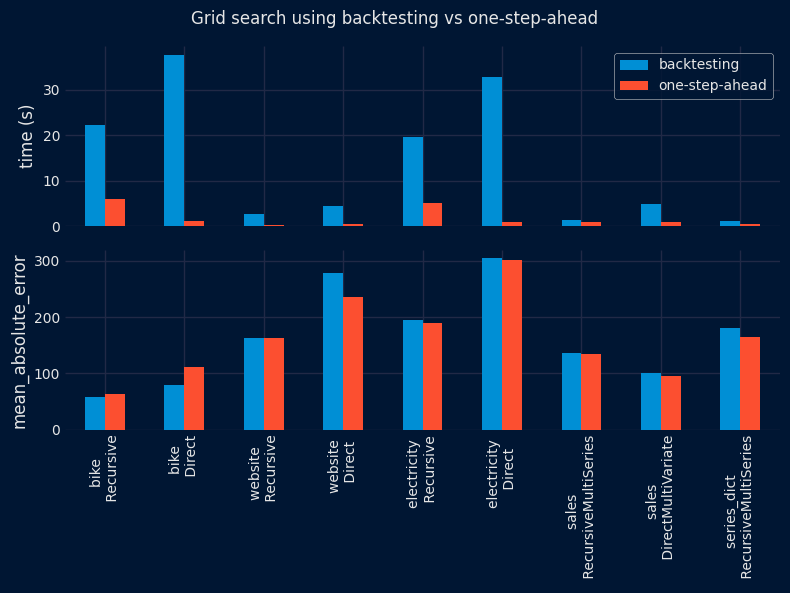

In [15]:
# Results
# ==============================================================================
summarize_results(
    results   = results_grid_search,
    metric    = metric,
    plot      = True,
    fig_size  = (8, 6),
    title     = 'Grid search using backtesting vs one-step-ahead',
    save_plot = "../img/grid_search_benchmark.png"
)

### Bayesian search

In [16]:
# Table to store results
# ==============================================================================
results_bayesian_search = []
metric = 'mean_absolute_error'

In [17]:
# Dataset bike_sharing_extended_features - ForecasterRecursive
# ==============================================================================
end_train = '2012-03-31 23:59:00'
end_validation = '2012-08-31 23:59:00'
exog_features = [
    'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'week_day_sin',
    'week_day_cos', 'hour_day_sin', 'hour_day_cos', 'sunrise_hour_sin', 'sunrise_hour_cos',
    'sunset_hour_sin', 'sunset_hour_cos', 'holiday_previous_day', 'holiday_next_day',
    'temp_roll_mean_1_day', 'temp_roll_mean_7_day', 'temp_roll_max_1_day',
    'temp_roll_min_1_day', 'temp_roll_max_7_day', 'temp_roll_min_7_day',
    'temp', 'holiday'
]

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'gamma'        : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'bike_sharing',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 37.29105830192566
Execution time one step ahead: 25.93167018890381
Same lags   : True
Same params : False

Method: backtesting
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'n_estimators': 1200, 'max_depth': 10, 'learning_rate': 0.01663211619538342, 'gamma': 0.9068212469825014, 'reg_alpha': 0.16016980526911573, 'reg_lambda': 0.24572731754447144}
    mean_absolute_error: 55.32660887147895

Method: one step ahead
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.04415387656318648, 'gamma': 0.6107399998271472, 'reg_alpha': 0.06335803380345338, 'reg_lambda': 0.43286258713180675}
    mean_absolute_error: 54.96555213565222


In [18]:
# Dataset bike_sharing_extended_features - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 steps         = 24,
                 lags          = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'bike_sharing',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 9.603635549545288
Execution time one step ahead: 0.2875657081604004
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': 241.9453241492509}
    mean_absolute_error: 79.31630982049967

Method: one step ahead
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'alpha': 15.094374246471325}
    mean_absolute_error: 111.96208734026862


In [19]:
# Dataset website_visits - ForecasterRecursive
# ==============================================================================
end_train = '2021-03-30 23:59:00'
end_validation = '2021-06-30 23:59:00'
exog_features = [col for col in data_website.columns if col.startswith(('month_', 'week_day_', 'month_day_'))]

forecaster = ForecasterRecursive(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10
             )

lags_grid = [7, 14, 21, [7, 14, 21]]


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    } 
    
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 7,
    metric                  = metric
)

results_bayesian_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 0.5441749095916748
Execution time one step ahead: 0.09021973609924316
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
    params : {'alpha': 7.076479975381038}
    mean_absolute_error: 140.5390247212754

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': 1.6754061464799246}
    mean_absolute_error: 165.40723118397938


In [20]:
# Dataset website_visits - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10,
                 steps         = 7
             )

lags_grid = [7, 14, 21, [7, 14, 21]]


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    } 
    
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 7,
    metric                  = metric
)

results_bayesian_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 0.8191888332366943
Execution time one step ahead: 0.10776948928833008
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
    params : {'alpha': 2.268443721999883}
    mean_absolute_error: 134.1189137011032

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': 1.6754061464799246}
    mean_absolute_error: 149.13783172855256


In [21]:
# Dataset vic_electricity - ForecasterRecursive
# ==============================================================================
end_train = '2013-06-30 23:59:00'
end_validation = '2013-11-30 23:59:00'
exog_features = ['Temperature', 'Holiday']

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'gamma'        : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    } 
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 36.96637010574341
Execution time one step ahead: 22.524948120117188
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'n_estimators': 900, 'max_depth': 8, 'learning_rate': 0.025967914628066663, 'gamma': 0.5944318794450425, 'reg_alpha': 0.5567851923942887, 'reg_lambda': 0.15895964414472274}
    mean_absolute_error: 194.97548125132678

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'n_estimators': 1200, 'max_depth': 10, 'learning_rat

In [22]:
# Dataset vic_electricity - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10,
                 steps         = 24
             )

lags_grid = (48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169))


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 8.585535049438477
Execution time one step ahead: 0.3147311210632324
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': 4.443990909384462}
    mean_absolute_error: 303.4857994388181

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': 0.7248908316801577}
    mean_absolute_error: 301.1634763513621


In [23]:
# Dataset sales - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2014-05-15 23:59:00'
end_validation = '2014-07-15 23:59:00'
levels = ['item_1', 'item_2', 'item_3']
exog_features = ['day_of_week']

forecaster = ForecasterRecursiveMultiSeries(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 encoding           = "ordinal",
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 series_weights     = None,
                 differentiation    = None,
                 dropna_from_series = False,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = [48, 72]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 200),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    } 
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 36,
    metric                  = metric
)

results_bayesian_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 2.997814178466797
Execution time one step ahead: 2.216564178466797
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'n_estimators': 99, 'max_depth': 7, 'learning_rate': 0.035621808879433586}
    114.33448196367536

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'n_estimators': 194, 'max_depth': 3, 'learning_rate': 0.05703347534789867}
    128.9354880927385


In [24]:
# Dataset sales - ForecasterDirectMultiVariate
# ==============================================================================
forecaster = ForecasterDirectMultiVariate(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 steps              = 5,
                 level              = 'item_1',
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = [48, 72]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 200),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 5,
    metric                  = metric
)

results_bayesian_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 12.84033465385437
Execution time one step ahead: 2.3266441822052
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'n_estimators': 194, 'max_depth': 3, 'learning_rate': 0.05703347534789867}
    97.80726797454876

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'n_estimators': 92, 'max_depth': 7, 'learning_rate': 0.10841835424476544}
    103.17828959392513


In [25]:
# Dataset series_dict - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2016-05-31 23:59:00'
end_validation = '2016-07-31 23:59:00'
levels = ['id_1000', 'id_1001', 'id_1002', 'id_1003', 'id_1004']
series_dict_train = {k: v.loc[: end_train,] for k, v in series_dict.items()}
exog_dict_train   = {k: v.loc[: end_train,] for k, v in exog_dict.items()}
series_dict_test  = {k: v.loc[end_train:,] for k, v in series_dict.items()}
exog_dict_test    = {k: v.loc[end_train:,] for k, v in exog_dict.items()}

forecaster_to_benchmark = ForecasterRecursiveMultiSeries(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 encoding           = "ordinal",
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 series_weights     = None,
                 differentiation    = None,
                 dropna_from_series = False,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )


def search_space(trial):
    search_space  = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth'   : trial.suggest_int('max_depth', 3, 7, step=1),
        'lags'        : trial.suggest_categorical('lags', [7, 14])
    } 
    return search_space


# Backtesting
forecaster = copy(forecaster_to_benchmark)
cv = TimeSeriesFold(
        initial_train_size = 100,
        steps              = 24,
        refit              = False,
     )
start  = time()
results_1, _ = bayesian_search_forecaster_multiseries(
                   forecaster         = forecaster,
                   series             = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                   exog               = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                   cv                 = cv,
                   search_space       = search_space,
                   n_trials           = 10,
                   metric             = metric,
                   return_best        = False,
                   n_jobs             = 'auto',
                   verbose            = False,
                   show_progress      = False,
                   suppress_warnings  = True
               )
end = time()
time_1 = end - start
best_params = results_1.loc[0, 'params']
best_lags = results_1.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)

cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False,
     )
metric_1, pred_1 = backtesting_forecaster_multiseries(
                       forecaster         = forecaster,
                       series             = series_dict,
                       exog               = exog_dict,
                       cv                 = cv,
                       levels             = levels,
                       metric             = metric,
                       verbose            = False,
                       show_progress      = False,
                       suppress_warnings  = True
                   )

# One step ahead
forecaster = copy(forecaster_to_benchmark)
cv = OneStepAheadFold(initial_train_size = 100)
start  = time()
results_2, _ = bayesian_search_forecaster_multiseries(
                   forecaster         = forecaster,
                   series             = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                   exog               = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                   cv                 = cv,
                   levels             = levels,
                   search_space       = search_space,
                   n_trials           = 10,
                   metric             = metric,
                   return_best        = False,
                   verbose            = False,
                   show_progress      = False,
                   suppress_warnings  = True
               )
end = time()
time_2 = end - start
best_params = results_2.loc[0, 'params']
best_lags = results_2.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)

cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False,
     )
metric_2, pred_2 = backtesting_forecaster_multiseries(
                       forecaster         = forecaster,
                       series             = series_dict,
                       exog               = exog_dict,
                       cv                 = cv,
                       levels             = levels,
                       metric             = metric,
                       verbose            = False,
                       show_progress      = False,
                       suppress_warnings  = True
                   )

print("Benchmark results")
print("-----------------")
print('Execution time backtesting   :', time_1)
print('Execution time one step ahead:', time_2)
print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
print("")
print("Method: backtesting")
print(f"    lags   : {results_1.loc[0, 'lags']}")
print(f"    params : {results_1.loc[0, 'params']}")
print(f"    {metric_1.loc[0, metric]}")
print("")
print("Method: one step ahead")
print(f"    lags   : {results_2.loc[0, 'lags']}")
print(f"    params : {results_2.loc[0, 'params']}")
print(f"    {metric_2.loc[0, metric]}")

results_bayesian_search.append([
    'series_dict',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1.loc[0, metric],
    metric_2.loc[0, metric],
])

Benchmark results
-----------------
Execution time backtesting   : 1.3268132209777832
Execution time one step ahead: 0.5007669925689697
Same lags   : True
Same params : True

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'n_estimators': 77, 'max_depth': 3}
    208.60243551060555

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'n_estimators': 77, 'max_depth': 3}
    208.60243551060555


,dataset,forecaster,time_search_backtesting,time_search_one_step,metric_backtesting,metric_one_step,ratio_speed,ratio_metric,dataset_forecaster
0,bike_sharing,ForecasterRecursive,37.291058,25.931670,55.326609,54.965552,1.44,1.01,bike_sharing \n Recursive
1,bike_sharing,ForecasterDirect,9.603636,0.287566,79.316310,111.962087,33.40,0.71,bike_sharing \n Direct
2,website,ForecasterRecursive,0.544175,0.090220,140.539025,165.407231,6.03,0.85,website \n Recursive
3,website,ForecasterDirect,0.819189,0.107769,134.118914,149.137832,7.60,0.90,website \n Direct
4,electricity,ForecasterRecursive,36.966370,22.524948,194.975481,204.701051,1.64,0.95,electricity \n Recursive
5,electricity,ForecasterDirect,8.585535,0.314731,303.485799,301.163476,27.28,1.01,electricity \n Direct
6,sales,ForecasterRecursiveMultiSeries,2.997814,2.216564,114.334482,128.935488,1.35,0.89,sales \n RecursiveMultiSeries
7,sales,ForecasterDirectMultiVariate,12.840335,2.326644,97.807268,103.178290,5.52,0.95,sales \n DirectMultiVariate
8,series_dict,ForecasterRecursiveMultiSeries,1.326813,0.500767,208.602436,208.602436,2.65,1.00,series_dict \n RecursiveMultiSeries


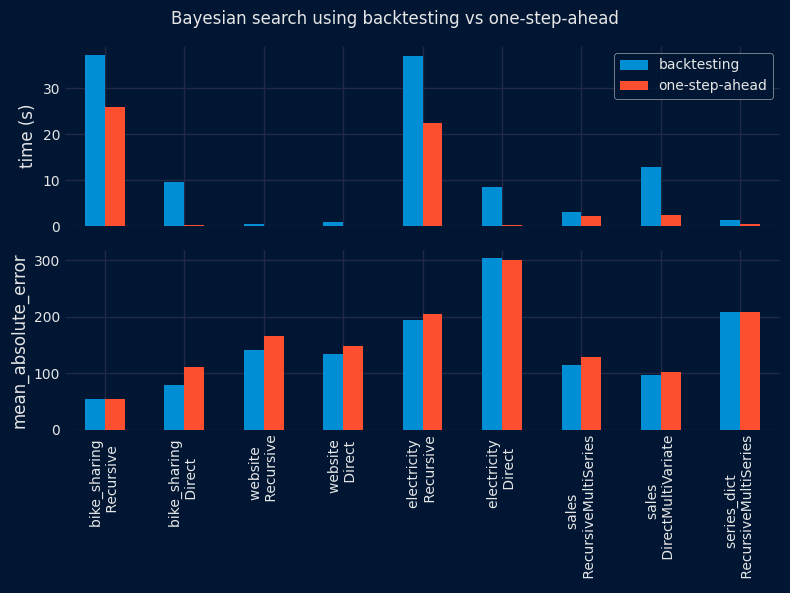

In [26]:
# Results
# ==============================================================================
summarize_results(
    results   = results_bayesian_search,
    metric    = metric,
    plot      = True,
    fig_size  = (8, 6),
    title     = 'Bayesian search using backtesting vs one-step-ahead',
    save_plot = "../img/bayesian_search_benchmark.png"
)